# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [ ]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [ ]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/postprocessed_csvs"

filename = "total_combined_cell.csv"
# filename = "total_combined_cell_borders_excluded.csv"
combined_cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(combined_cell_df_mitolyso.shape)
# print(cell_df.shape, " ", filter_df.shape)

# extrafeatures_filtered_cell_df_mitolyso = plate_df_setup(curr_plates, curr_plate_datafolders, parent_dir, ['Cell.csv', 'Nuclei.csv','MergedMitoPerCell.csv','MergedLysoPerCell.csv'])

filename_borders_excluded = "total_combined_cell_borders_excluded.csv"


def fix_column_names(df):
    # remove "Cells_" from the beginning of column names
    df.columns = df.columns.str.replace(r"^Cell_", "", regex=True)
    # also rename nuclei cols in the filtered df when you made the df one-to-one
    df.columns = df.columns.str.replace(r"^Mean_Nuclei_", "Nuclei_", regex=True)
    df["Cell_Nuclei_Area_Ratio"] = df[
        "Nuclei_Area_Ratio"
    ]  # dupe column with the old name back
    unique_ID_df = df.reset_index().rename(
        columns={"index": "Cell_Unique_ID"}  # add a unique ID
    )
    return unique_ID_df


combined_cell_df_mitolyso = fix_column_names(combined_cell_df_mitolyso)

In [ ]:
unique_combinations = combined_cell_df_mitolyso[
    ["Plate_Number", "PassageNumber"]
].drop_duplicates()

combos = list(unique_combinations.itertuples(index=False, name=None))
# display(sorted(combos))
display(combined_cell_df_mitolyso)

In [ ]:
def normalize_intensity_to_well_average(df, intensity_cols, drop_well_avg_cols=False):
    # Create a new DataFrame to store the normalized values
    normalized_df = df.copy()

    # Group by 'Plate_Number' and 'Metadata_Well' to calculate the average intensity for each well
    well_averages = (
        df.groupby(["Plate_Number", "Metadata_Well"])[intensity_cols]
        .mean()
        .reset_index()
    )

    # Merge the well averages back to the original DataFrame
    normalized_df = normalized_df.merge(
        well_averages, on=["Plate_Number", "Metadata_Well"], suffixes=("", "_WellAvg")
    )

    # Normalize the intensity columns by dividing by the well average
    for col in intensity_cols:
        new_name = f"{col}_WellNormalized"
        normalized_df[new_name] = normalized_df[col] / normalized_df[f"{col}_WellAvg"]

    # Drop the well average columns
    if drop_well_avg_cols:
        normalized_df.drop(
            columns=[f"{col}_WellAvg" for col in intensity_cols], inplace=True
        )

    return normalized_df


intensity_cols = [
    col
    for col in combined_cell_df_mitolyso.columns
    # regex to match columns that contain Nuclei_Intensity, our desired intensity cols (MaxIntensity_DAPI, MeanIntensity_DAPI), and ends with _MAX
    if re.search(
        r"^((?=.*Nuclei_Intensity)(?=.*(?:MaxIntensity_DAPI|MeanIntensity_DAPI|MinIntensity_DAPI|MedianIntensity_DAPI))(?=.*_MAX))",
        col,
    )
]
well_avg_cols = [f"{col}_WellAvg" for col in intensity_cols]
norm_intensity_cols = [f"{col}_WellNormalized" for col in intensity_cols]

combined_cell_df_mitolyso_test = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso.copy(), intensity_cols
)
display(
    combined_cell_df_mitolyso_test[
        ["AllGroups", "Plate_Number", "Metadata_Well"]
        + intensity_cols
        + well_avg_cols
        + norm_intensity_cols
    ].head(20)
)

combined_cell_df_mitolyso = normalize_intensity_to_well_average(
    combined_cell_df_mitolyso, intensity_cols
)

In [ ]:
def normalize_quantities_to_control_group_average(
    df,
    quantitiy_cols,
    group_col,
    control_value,
    plate_number_col="Plate_Number",
    overwrite=False,
    drop_avg_cols=False,
):
    # Create a new DataFrame to store the normalized values
    normalized_df = df.copy()

    # find average of the control group for each plate
    ctrl_averages = (
        df[df[group_col] == control_value]
        .groupby([plate_number_col])[quantitiy_cols]
        .mean()
        .reset_index()
    )
    display(ctrl_averages)
    # Merge the control averages back to the original DataFrame
    normalized_df = normalized_df.merge(
        ctrl_averages, on=[plate_number_col], suffixes=("", "_CtrlAvg")
    )

    # Normalize the intensity columns by dividing by the well average
    for col in quantitiy_cols:
        new_name = f"{col}_CtrlNormalized"
        if overwrite:
            normalized_df[col] = normalized_df[col] / normalized_df[f"{col}_CtrlAvg"]
        else:
            if new_name not in normalized_df.columns:
                normalized_df[new_name] = (
                    normalized_df[col] / normalized_df[f"{col}_CtrlAvg"]
                )

    # Drop the well average columns
    if drop_avg_cols:
        normalized_df.drop(
            columns=[f"{col}_CtrlAvg" for col in quantitiy_cols], inplace=True
        )

    return normalized_df


# quantitiy_cols = [
#     col
#     for col in combined_cell_df_mitolyso.columns
#     if re.search(
#         r"^((?=.*Mean_))",
#         col,
#     )
# ]
# group_col = "AgeGroup"
# control_value = 0
# norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
#     combined_cell_df_mitolyso.copy(), quantitiy_cols, group_col, control_value, overwrite=True, drop_avg_cols=True
# )
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + quantitiy_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="Plate_Number")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number","AgeGroup"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

## Debugging functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

In [ ]:
def enforce_objects_one_to_one(
    df,
    parent_obj="Cell",
    child_obj="Nuclei",
    parent_colname="Cell_AreaShape_Area",
    child_colname="Cell_Mean_Nuclei_AreaShape_Area",
):
    """apply filters based on the number of nuclei to remove to enforce a 1:1 cell-nucleus relationship:
    - Cells that have less or more than one nucleus
    - Poorly segmented cells where the cell area is smaller than the nuclei area
    - Image is not flagged as empty by CellProfiler
    Can also use other objects instead of nuclei

    Args:
        df (DataFrame): The parent dataframe
        child_obj (str, optional): _description_. Defaults to "Nuclei".
        parent_colname (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        child_colname (str, optional): _description_. Defaults to "Cell_Mean_Nuclei_AreaShape_Area".

    Returns:
        DataFrame: the filtered dataframe with the removed objects
    """
    if child_obj == "Nuclei" and parent_obj == "Cell":
        try:
            not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
            normal_cells = not_empty_df[
                not_empty_df["Cell_Classify_one_nuc"] == 1
            ]  # one nucleus only
        except KeyError as e:
            print(f"KeyError {e}; skipping emptyimage")
            normal_cells = df[df["Cell_Classify_one_nuc"] == 1]
        # remove if my cell area is bigger than nuclear area
        size_filtered_cells = normal_cells[
            normal_cells[parent_colname] > normal_cells[child_colname]
        ]
        final_df = size_filtered_cells.reset_index(drop=True)
        return final_df
    else:
        # just do the size excludion
        not_empty_df = df[df["Metadata_EmptyImage_Cells"] == 0]
        size_filtered_cells = not_empty_df[
            not_empty_df[parent_colname] > not_empty_df[child_colname]
        ]
        return size_filtered_cells


def filter_nuclei_outisde_bbox(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_nuclei_with_bbox_overlap(overlapped_df, nuc_prefix="Nuclei", cell_prefix=""):
    df = overlapped_df.copy()
    # Get the coordinate of the cell and nuclei objects
    # Note- make sure the cells and nuclei are 1:1 or this will fail
    if len(df[f"{nuc_prefix}_AreaShape_Area"]) != len(
        df[f"{cell_prefix}_AreaShape_Area"]
    ):
        return ValueError

    nuc_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"]
    )  # the diameter of the cell on x axis
    nuc_delta_x = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"]
        - df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"]
    )  # the diameter of the cell on x axis

    nuc_min_x, nuc_min_y, nuc_max_x, nuc_max_y = (
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMinimum_Y"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_X"],
        df[f"{nuc_prefix}_AreaShape_BoundingBoxMaximum_Y"],
    )
    cell_min_x, cell_min_y, cell_max_x, cell_max_y = (
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMinimum_Y"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_X"],
        df[f"{cell_prefix}AreaShape_BoundingBoxMaximum_Y"],
    )
    # now get two boolean series that match the conditions
    df_is_contained_x = (nuc_min_x >= cell_min_x) & (nuc_max_x <= cell_max_x)
    df_is_contained_y = (nuc_min_y >= cell_min_y) & (nuc_max_y <= cell_max_y)
    # and then we get the subset of the dataframe where both are true
    df_is_contained_xy = df[df_is_contained_x & df_is_contained_y]

    final_df = df_is_contained_xy.reset_index(drop=True)
    return final_df


def filter_out_empty_compartment_from_cells(
    df, organelle, prefix="", min_compartments=1
):
    """Remove rows from a dataframe where a parent "cell" object doesn't have any child objects of {organelle}

    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    organelle = organelle.title()
    this_df = df.copy()
    atleast_one_df = this_df[
        this_df[f"{prefix}Children_{organelle}_Count"] > min_compartments
    ].reset_index(drop=True)
    return atleast_one_df


def hard_size_filter_rows_in_df(
    df,
    area_col="Nuclei_AreaShape_Area",
    prefix="",
    min_threshold=5000,
    max_threshold=np.inf,
):
    """Remove rows from a dataframe that are above a size theshold
    Args:
        df (DataFrame): _description_
        organelle (str): the organelle in plural. Typically "Mitochondria or Lysosomes (or Nuclei)
        prefix (str, optional): _description_. Defaults to "".

    Returns:
        Dataframe: _description_
    """
    data_df = df.copy()
    data_df = data_df[data_df[prefix + area_col] > min_threshold]
    data_df = data_df[data_df[prefix + area_col] < max_threshold]
    final_df = data_df.reset_index(drop=True)
    return final_df


def filter_out_images_with_n_cells(
    df, n, image_count_col="Image_Count_Cell", prefix=""
):
    filter_df = df.copy()
    filter_df = filter_df[image_count_col] > n
    final_df = filter_df.reset_index(drop=True)
    return final_df


def get_min_max_percentile_thesholds(
    df,
    column,
    min_percentile=0.025,
    max_percentile=0.975,
    subset_col="",
    min_subset_group=None,
    max_subset_group=None,
):
    if subset_col:
        if subset_col not in df.columns:
            raise ValueError(f"Subset column {subset_col} not found in dataframe")
        if min_subset_group is not None:
            df_min = df[df[subset_col] == min_subset_group]
            min_threshold = df_min[column].quantile(min_percentile)
            # print(f"Min {column} threshold for {min_subset_group}: {min_threshold}")
        else:
            min_threshold = df[column].min()

        if max_subset_group is not None:
            df_max = df[df[subset_col] == max_subset_group]
            max_threshold = df_max[column].quantile(max_percentile)
            # print(f"Max {column} threshold for {max_subset_group}: {max_threshold}")
        else:
            max_threshold = df[column].max()

    else:
        min_threshold = df[column].quantile(min_percentile)
        max_threshold = df[column].quantile(max_percentile)

    return min_threshold, max_threshold


def apply_all_filters(
    df,
    reference_df=None,  # optional df to use for calculating the thresholds to avoid biasing the thresholds by the filters
    nuc_size_min_threshold_percentile=0.025,
    nuc_size_max_threshold_percentile=0.975,
    cell_size_min_threshold_percentile=0.025,
    cell_size_max_threshold_percentile=0.975,
    cell_nuc_area_minthreshold_percentile=0.025,
    cell_nuc_area_maxthreshold_percentile=0.975,
    min_cell_count=0,
    min_nuc_intensity_percentile=0.025,
    max_nuc_intensity_percentile=0.975,
    max_neighbours_percenttouching_percentile=0.975,
    max_neighbours_numberof_percentile=0.975,
    max_nuc_neighbours_numberof_percentile=0.975,
    cell_nuc_ratio_col="Cell_Nuclei_Area_Ratio",
    area_col="AreaShape_Area",
    nuc_area_col="Nuclei_AreaShape_Area",
    neighbours_col_percenttouching="Neighbors_PercentTouching_5",
    neighbours_col_numberof="Neighbors_NumberOfNeighbors_5",
    nuc_neighbours_col_numberof="Nuclei_Neighbors_NumberOfNeighbors_1",
    image_count_col="Image_Count_Cell",
    norm_nuc_intensity_cols=[],
    min_compartments=0,
):
    filtered_df = (
        df  # enforce_objects_one_to_one(df)  # , child_colname="Nuclei_AreaShape_Area")
    )
    if reference_df is not None:
        reference_df = reference_df.copy()
    else:
        reference_df = filtered_df.copy()

    # filter out the cells wo compartments
    filter_df_1 = filter_out_empty_compartment_from_cells(
        filtered_df, "mitochondria", min_compartments=min_compartments
    )
    filter_df_2 = filter_out_empty_compartment_from_cells(
        filter_df_1, "lysosomes", min_compartments=min_compartments
    )

    # cell size filter
    min_threshold_cell_size, max_threshold_cell_size = get_min_max_percentile_thesholds(
        reference_df,
        area_col,
        min_percentile=cell_size_min_threshold_percentile,
        max_percentile=cell_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filter_df_cell_size = hard_size_filter_rows_in_df(
        filter_df_2,
        min_threshold=min_threshold_cell_size,
        max_threshold=max_threshold_cell_size,
        area_col=area_col,
        prefix="",
    )
    # nuc size filter (using untrimmed df to get the thresholds to avoid biasing the thresholds by the cell size filter)
    min_threshold_nuc_size, max_threshold_nuc_size = get_min_max_percentile_thesholds(
        reference_df,
        nuc_area_col,
        min_percentile=nuc_size_min_threshold_percentile,
        max_percentile=nuc_size_max_threshold_percentile,
        subset_col="AllGroups",
        min_subset_group="P6-12",
        max_subset_group="Doxo",
    )
    filter_df_nuc_size = hard_size_filter_rows_in_df(
        filter_df_cell_size,
        min_threshold=min_threshold_nuc_size,
        max_threshold=max_threshold_nuc_size,
        area_col=nuc_area_col,
        prefix="",
    )

    # cell:nuc ratio filter
    min_cell_nuc_ratio_threshold, max_cell_nuc_ratio_threshold = (
        get_min_max_percentile_thesholds(
            reference_df,
            cell_nuc_ratio_col,
            min_percentile=cell_nuc_area_minthreshold_percentile,
            max_percentile=cell_nuc_area_maxthreshold_percentile,
            subset_col="AllGroups",
            min_subset_group="P6-12",
            max_subset_group="Doxo",
        )
    )
    filter_df_minratio = filter_df_nuc_size[
        filter_df_nuc_size[cell_nuc_ratio_col] > min_cell_nuc_ratio_threshold
    ]
    filter_df_maxratio = filter_df_minratio[
        filter_df_minratio[cell_nuc_ratio_col] < max_cell_nuc_ratio_threshold
    ]

    # nuc intensity filter
    if norm_nuc_intensity_cols:
        filter_df_loop = filter_df_maxratio.copy()
        min_filtered_dfs = []
        max_filtered_dfs = []
        thresholds = []
        for col in norm_nuc_intensity_cols:
            min_nuc_intensity_threshold, max_nuc_intensity_threshold = (
                get_min_max_percentile_thesholds(
                    reference_df,
                    col,
                    min_percentile=min_nuc_intensity_percentile,
                    max_percentile=max_nuc_intensity_percentile,
                    subset_col="AllGroups",
                    min_subset_group="P6-12",
                    max_subset_group="P6-12",
                )
            )
            print(f"Min {col} threshold: {min_nuc_intensity_threshold}")
            print(f"Max {col} threshold: {max_nuc_intensity_threshold}")
            filter_df_nuclei_minintensity = filter_df_loop[
                filter_df_loop[col] > min_nuc_intensity_threshold
            ]
            min_filtered_dfs.append(filter_df_nuclei_minintensity)

            filter_df_nuclei_maxintensity = filter_df_nuclei_minintensity[
                filter_df_nuclei_minintensity[col] < max_nuc_intensity_threshold
            ]
            max_filtered_dfs.append(filter_df_nuclei_maxintensity)
            filter_df_loop = filter_df_nuclei_maxintensity.copy()
            thresholds.append(
                (min_nuc_intensity_threshold, max_nuc_intensity_threshold)
            )

        filter_df_nuclei_minintensity = min_filtered_dfs[-1]
        filter_df_nuclei_maxintensity = max_filtered_dfs[-1]
        min_nuc_intensity_threshold = thresholds[-1][0]
        max_nuc_intensity_threshold = thresholds[-1][1]
    else:
        # if not using this filter, just set the min and max intensity filtered dfs to be the same as the previous filter so that the rest of the filters can run without error
        filter_df_nuclei_minintensity = filter_df_maxratio.copy()
        filter_df_nuclei_maxintensity = filter_df_nuclei_minintensity.copy()
        min_nuc_intensity_threshold = None
        max_nuc_intensity_threshold = None

    # more than one cell filter (not using)
    filter_df_morethanonecell = filter_df_nuclei_maxintensity[
        filter_df_nuclei_maxintensity[image_count_col] > min_cell_count
    ]

    # neighbors filters
    max_threshold_neighbours_percenttouching = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_percenttouching,
        min_percentile=0,
        max_percentile=max_neighbours_percenttouching_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    max_threshold_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    filter_df_neigbours = filter_df_morethanonecell[
        (
            filter_df_morethanonecell[neighbours_col_percenttouching]
            < max_threshold_neighbours_percenttouching
        )
        & (
            filter_df_morethanonecell[neighbours_col_numberof]
            < max_threshold_neighbours_numberof
        )
    ]  # optional filter for touching neighbors AND number of neighbors

    max_threshold_nuc_neighbours_numberof = get_min_max_percentile_thesholds(
        reference_df,
        nuc_neighbours_col_numberof,
        min_percentile=0,
        max_percentile=max_nuc_neighbours_numberof_percentile,
        subset_col="AllGroups",
        max_subset_group="P6-12",
    )[1]
    filter_df_nuc_neigbours_numberof = filter_df_neigbours[
        filter_df_neigbours[nuc_neighbours_col_numberof]
        <= max_threshold_nuc_neighbours_numberof
    ]  # optional filter for number of neighbouring nuclei

    final_filtered_df = (
        filter_df_nuc_neigbours_numberof.copy()
    )  # or filter_df_size if you want the size filter

    # Create a dictionary to store filtering summary
    filtering_summary = {
        "OG_df": {
            "filter_type": "Original",
            "rows": df.shape[0],
            "columns": df.shape[1],
            "rows_removed": 0,
            "threshold": f"{None},{None}",
        },
        "Filtered_df": {
            "filter_type": "Initial Column Filter",
            "rows": filtered_df.shape[0],
            "columns": filtered_df.shape[1],
            "rows_removed": df.shape[0] - filtered_df.shape[0],
            "threshold": f"{None},{None}",
        },
        "Empty_Mitochondria_Removed": {
            "filter_type": "Remove Empty Mitochondria",
            "rows": filter_df_1.shape[0],
            "columns": filter_df_1.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_1.shape[0],
            "threshold": f"{min_compartments},{None}",
        },
        "Empty_Lysosomes_Removed": {
            "filter_type": "Remove Empty Organelles",
            "rows": filter_df_2.shape[0],
            "columns": filter_df_2.shape[1],
            "rows_removed": filtered_df.shape[0] - filter_df_2.shape[0],
            "threshold": f"{min_compartments},{None}",
        },
        "Cell_Size_Thresholded": {
            "filter_type": "Cell Size Threshold",
            "rows": filter_df_cell_size.shape[0],
            "columns": filter_df_cell_size.shape[1],
            "rows_removed": filter_df_2.shape[0] - filter_df_cell_size.shape[0],
            "threshold": f"{min_threshold_cell_size},{max_threshold_cell_size}",
        },
        "Nuc_Size_Thresholded": {
            "filter_type": "Nuclei Size Threshold",
            "rows": filter_df_nuc_size.shape[0],
            "columns": filter_df_nuc_size.shape[1],
            "rows_removed": filter_df_cell_size.shape[0] - filter_df_nuc_size.shape[0],
            "threshold": f"{min_threshold_nuc_size},{max_threshold_nuc_size}",
        },
        "Cell_Nuclei_Ratio_MinFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_minratio.shape[0],
            "columns": filter_df_minratio.shape[1],
            "rows_removed": filter_df_cell_size.shape[0] - filter_df_minratio.shape[0],
            "threshold": f"{min_cell_nuc_ratio_threshold},{0}",
        },
        "Cell_Nuclei_Ratio_MaxFilter": {
            "filter_type": "Cell:Nuclei Ratio Threshold",
            "rows": filter_df_maxratio.shape[0],
            "columns": filter_df_maxratio.shape[1],
            "rows_removed": filter_df_minratio.shape[0] - filter_df_maxratio.shape[0],
            "threshold": f"{0},{max_cell_nuc_ratio_threshold}",
        },
        "Nuclei_Min_Intensity_Filtered": {
            "filter_type": "Nuclei Minimum Intensity",
            "rows": filter_df_nuclei_minintensity.shape[0],
            "columns": filter_df_nuclei_minintensity.shape[1],
            "rows_removed": filter_df_maxratio.shape[0]
            - filter_df_nuclei_minintensity.shape[0],
            "threshold": f"{min_nuc_intensity_threshold},{None}",
        },
        "Nuclei_Max_Intensity_Filtered": {
            "filter_type": "Nuclei Maxiumum Intensity",
            "rows": filter_df_nuclei_maxintensity.shape[0],
            "columns": filter_df_nuclei_maxintensity.shape[1],
            "rows_removed": filter_df_nuclei_minintensity.shape[0]
            - filter_df_nuclei_maxintensity.shape[0],
            "threshold": f"{None},{max_nuc_intensity_threshold}",
        },
        "More_Than_One_Cell": {
            "filter_type": "More Than One Cell",
            "rows": filter_df_morethanonecell.shape[0],
            "columns": filter_df_morethanonecell.shape[1],
            "rows_removed": filter_df_nuclei_maxintensity.shape[0]
            - filter_df_morethanonecell.shape[0],
            "threshold": f"{min_cell_count},{None}",
        },
        "Neighbors_PercentTouching AND_NumberOf_Filtered": {
            "filter_type": "Neighbors Percent Touching < 97.5th Percentile",
            "rows": filter_df_neigbours.shape[0],
            "columns": filter_df_neigbours.shape[1],
            "rows_removed": filter_df_morethanonecell.shape[0]
            - filter_df_neigbours.shape[0],
            "threshold": f"{None},{max_threshold_neighbours_percenttouching} and {None},{max_threshold_neighbours_numberof}",
        },
        # "Neighbors_Filtered NumberOf": {
        #     "filter_type": "Number of Neighbors < 97.5th Percentile",
        #     "rows": filter_df_neigbours_numberof.shape[0],
        #     "columns": filter_df_neigbours_numberof.shape[1],
        #     "rows_removed": filter_df_neigbours_percenttouching.shape[0]
        #     - filter_df_neigbours_numberof.shape[0],
        # },
        "Nuc_Neighbors_Filtered NumberOf": {
            "filter_type": "Number of Nucleus Neighbors < 97.5th Percentile",
            "rows": filter_df_nuc_neigbours_numberof.shape[0],
            "columns": filter_df_nuc_neigbours_numberof.shape[1],
            "rows_removed": filter_df_neigbours.shape[0]
            - filter_df_nuc_neigbours_numberof.shape[0],
            "threshold": f"{None},{max_threshold_nuc_neighbours_numberof}",
        },
        "Final_Filtered_df": {
            "filter_type": "Final Filtered DataFrame",
            "rows": final_filtered_df.shape[0],
            "columns": final_filtered_df.shape[1],
            "rows_removed": filter_df_nuc_neigbours_numberof.shape[0]
            - final_filtered_df.shape[0],
            "threshold": f"{None} See above filters",
        },
    }

    # return both to export as CSV
    return final_filtered_df, filtering_summary


# get a per-plate breakdown of the filtering summary to see if some plates are more affected by the filters than others
plates = combined_cell_df_mitolyso["Plate_Number"].unique()
summary_dfs = []
for plate in plates:
    plate_df = combined_cell_df_mitolyso[
        combined_cell_df_mitolyso["Plate_Number"] == plate
    ]
    plate_filtered_df, plate_filtering_summary = apply_all_filters(
        plate_df,
        combined_cell_df_mitolyso,  # , norm_nuc_intensity_cols=norm_intensity_cols
    )

    plate_summary_df = pd.DataFrame.from_dict(plate_filtering_summary, orient="index")
    plate_summary_df["Plate_Number"] = (
        f"Plate {int(plate)}"  # add the plate number back to the summary df
    )
    summary_dfs.append(plate_summary_df)


final_filtered_summary_plate_df = pd.concat(summary_dfs, axis=0).reset_index(drop=True)
final_filtered_summary_plate_pivot = final_filtered_summary_plate_df.pivot_table(
    index="filter_type",
    columns="Plate_Number",
    values="rows_removed",
    aggfunc="first",
    fill_value=0,
).sort_index()

final_filtered_summary_plate_df.to_csv("filtering_summary_all_plates.csv")
final_filtered_summary_plate_pivot.to_csv("filtering_summary_all_plates_pivot.csv")

In [ ]:
# get the overall filtering summary for the whole dataset
final_filtered_df, filtering_summary = apply_all_filters(
    combined_cell_df_mitolyso,
    combined_cell_df_mitolyso,
    norm_nuc_intensity_cols=norm_intensity_cols,
)
final_filtered_summary_df = pd.DataFrame.from_dict(filtering_summary, orient="index")
final_filtered_summary_df.to_csv("filtering_summary.csv")


In [ ]:
# test out the colour dict
colour_dict = get_hard_code_plate_colours(final_filtered_df)
# display(colour_dict)
# print(colour_dict[6])


## Search Column Names

In [ ]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(final_filtered_df, "DAPI")
display(final_filtered_df[colnames])

In [ ]:
# display(combined_cell_df_mitolyso[['Cell_AreaShape_Area', 'Cell_Children_Mitochondria_Count','Cell_Mean_Mitochondria_AreaShape_Area']])
display(
    final_filtered_df[
        [
            "AreaShape_Area",
            "Children_Mitochondria_Count",
            "Mean_Mitochondria_AreaShape_Area",
        ]
    ]
)


# Define the cell features


In [ ]:
# Add extra columns
def proportion_area_occupied_per_cell(df, compartment):
    # proportion of area occupied = children * mean organelle area / cell area
    colname = "Total_Area_Proportion_" + compartment + "_Per_Cell"

    # children = 'Children_' + compartment + '_Count'
    # mean_organelle_area = 'Mean_'+ compartment + '_AreaShape_Area'
    organelle_area = compartment + "_AreaShape_Area"
    cell_area = "AreaShape_Area"
    # df[colname] = df.apply(lambda x: (x[children] * x[mean_organelle_area]) / x[cell_area], axis=1)
    df[colname] = df.apply(lambda x: (x[organelle_area]) / x[cell_area], axis=1)
    return df[colname]


def mean_intensity_per_compartment_per_cell(df, compartment, name, tag, math=None):
    # Calculate the mean intensity of each compartment per cell
    # mean_intesity_per_compartment = integrated / (children*mean_area)
    colname = f"Mean_Intensity_Per_{compartment} Per_Cell"
    integrated = "Intensity_IntegratedIntensity_" + tag
    # children = 'Children_' + compartment + '_Count'
    # mean_area = 'Mean_'+ compartment + '_AreaShape_Area'
    total_organelle_area = name + "_AreaShape_Area"
    total_organelle_area = math if math is not None else total_organelle_area

    df[colname] = df.apply(lambda x: x[integrated] / x[total_organelle_area], axis=1)

    return df[colname]


# df["Mean_Mitochondria_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(extrafeatures_filtered_cell_df_mitolyso, "MergedMitoPerCell")
# df["Mean_Lysosomes_Area_PerCell_Ratio"]  = proportion_area_occupied_per_cell(df, "MergedLysoPerCell")

# df["MeanIntensity_Lysosomes_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(extrafeatures_filtered_cell_df_mitolyso, "Lysosomes", "MergedLysoPerCell", "LAMP1")
# df["MeanIntensity_Mitochondria_PerCell_Ratio"] = mean_intesity_per_compartment_per_cell(df, "Mitochondria", "MergedMitoPerCell", "MitoTracker")


# Calculate the total area occupied by mitochondria and lysosomes per cell
def calculate_corrected_features(full_df):
    """_summary_

    Args:
        full_df (DataFrame): _description_

    Returns:
        df (DataFrame): the df with all the feature calcs
    """
    df = full_df.copy()
    df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Count"] * df["Mean_Mitochondria_AreaShape_Area"]
    )
    df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] = (
        df["Children_Lysosomes_Count"] * df["Mean_Lysosomes_AreaShape_Area"]
    )
    df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"] = (
        df["Children_Mitochondria_Puncta_Count"]
        * df["Mean_Mitochondria_Puncta_AreaShape_Area"]
    )

    # Total intensity per cell based on integrated instensity if I don't already have the merged area
    df["Mean_Intensity_Per_Lysosomes_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Lysosomes",
            "MergedLysoPerCell",
            "LAMP1",
            math="Math_Total_Lysosomes_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria",
            "MergedMitoPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_AreaShape_Area_PerCell",
        )
    )
    df["Mean_Intensity_Per_Mitochondria_Puncta_PerCell_Area"] = (
        mean_intensity_per_compartment_per_cell(
            df,
            "Mitochondria_Puncta",
            "MergedMitoPunctaPerCell",
            "MitoTracker",
            math="Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell",
        )
    )
    # #same thing but for medians
    # df["Median_Intensity_Per_Lysosomes_PerCell_Area"] = (
    #     df["Children_Lysosomes_Count"]
    #     * df["Mean_Lysosomes_Intensity_MeanIntensity_LAMP1"]
    # )
    # df["Median_Intensity_Per_Mitochondria_PerCell_Area"] = (
    #     df["Children_Mitochondria_Count"]
    #     * df["Mean_Mitochondria_Intensity_MeanIntensity_MitoTracker"]
    # )

    # Corrected mitochondria and lysosomes counts per cell area (density)
    df["Density_Children_Mitochondria_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Lysosomes_Count_PerCell_Area"] = (
        df["Children_Lysosomes_Count"] / df["AreaShape_Area"]
    )
    df["Density_Children_Mitochondria_Puncta_Count_PerCell_Area"] = (
        df["Children_Mitochondria_Puncta_Count"] / df["AreaShape_Area"]
    )

    # organelle area fractions per cell ratio
    df["OccupiedAreaFraction_Mitochondria_PerCell_Area"] = (
        df["Math_Total_Mitochondria_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Mitochondria_Puncta_PerCell_Area"] = (
        df["Math_Total_Mitochondria_Puncta_AreaShape_Area_PerCell"]
        / df["AreaShape_Area"]
    )
    df["OccupiedAreaFraction_Lysosomes_PerCell_Area"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"] / df["AreaShape_Area"]
    )

    # Compartment diameter ratios
    df["Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Mean_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Mitochondria_DiameterRatio_PerCell"] = (
        df["Median_Mitochondria_AreaShape_MaxFeretDiameter"]
        / df["Median_Mitochondria_AreaShape_MinFeretDiameter"]
    )
    df["Median_Lysosomes_DiameterRatio_PerCell"] = (
        df["Median_Lysosomes_AreaShape_MaxFeretDiameter"]
        / df["Median_Lysosomes_AreaShape_MinFeretDiameter"]
    )
    df["Mean_Mitochondria_Puncta_MaxMinFeret_DiameterRatio_PerCell"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
        / df["Mean_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    )
    # df["Median_Mitochondria_Puncta_DiameterRatio_PerCell"] = (
    #     df["Median_Mitochondria_Puncta_AreaShape_MaxFeretDiameter"]
    #     / df["Median_Mitochondria_Puncta_AreaShape_MinFeretDiameter"]
    # )

    # mean and median area per organelle per cell area
    df["Mean_Mitochondria_Area_PerCell_Area"] = (
        df["Mean_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Area_PerCell_Area"] = (
        df["Mean_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta)Area_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Mitochondria_Area_PerCell_Area"] = (
        df["Median_Mitochondria_AreaShape_Area"] / df["AreaShape_Area"]
    )
    df["Median_Lysosomes_Area_PerCell_Area"] = (
        df["Median_Lysosomes_AreaShape_Area"] / df["AreaShape_Area"]
    )

    # mitolyso related
    df["Children_Lysosomes_Mitochondria_Ratio"] = (
        df["Children_Lysosomes_Count"] / df["Children_Mitochondria_Count"]
    )
    df["Density_Lysosomes_Mitochondria_Ratio"] = (
        df["OccupiedAreaFraction_Lysosomes_PerCell_Area"]
        / df["OccupiedAreaFraction_Mitochondria_PerCell_Area"]
    )
    df["Area_Lysosomes_Mitochondria_Ratio"] = (
        df["Math_Total_Lysosomes_AreaShape_Area_PerCell"]
        / df["Math_Total_Mitochondria_AreaShape_Area_PerCell"]
    )

    # Quin's Ratio: Ratio of centroid distance to minimum distance for mitochondria and lysosomes
    # increase = more peripheral, decrease = more nuclear
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Nuclei"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Distance_Minimum_Cell"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"]
        / df["Mean_Lysosomes_Distance_Minimum_Cell"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_Minimum_Cell_QuinRatio"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei"]
        / df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"]
    )
    # Distance to parents percellarea
    df["Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Lysosomes_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Lysosomes_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    df["Mean_Mitochondria_Puncta_Distance_Centroid_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Distance_Centroid_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Centroid_Cell"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Nuclei"] / df["AreaShape_Area"]
    )
    df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell_PerCell_Area"] = (
        df["Mean_Mitochondria_Puncta_Distance_Minimum_Cell"] / df["AreaShape_Area"]
    )

    # transform the mitoends - number of ends times the mean to get total per cell
    df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"]
    )
    df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberNonTrunkBranches_MtSkltn"]
    )
    df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_NumberTrunks_MitoSkeleton"]
    )
    df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] = (
        df["Children_MitoEnds_Count"]
        * df["Mean_MitoEnds_ObjectSkeleton_TotalObjectSkeltnLngth_MtSkltn"]
    )
    # now divide these by cell area
    df["MitoEnds_NumberBranchEnds_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberNonTrunkBranches_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["MitoEnds_NumberTrunks_PerCell_Area"] = (
        df["MitoEnds_Math_Total_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["MitoEnds_TotalObjectSkeltnLngth_PerCell_Area"] = (
        df["MitoEnds_Math_TotalObjectSkeltnLngth_MitoSkeleton"] / df["AreaShape_Area"]
    )

    # also the nuclear mito skeleton features per cell area
    df["Nuclei_ObjectSkeleton_NumberBranchEnds_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberBranchEnds_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberNonTrunkBranches_MitoSkeleton"]
        / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_NumberTrunks_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_NumberTrunks_MitoSkeleton"] / df["AreaShape_Area"]
    )
    df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_PerCell_Area"] = (
        df["Nuclei_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkeleton"]
        / df["AreaShape_Area"]
    )

    return df


extrafeatures_filtered_cell_df_mitolyso = calculate_corrected_features(
    final_filtered_df
)
# display(extrafeatures_filtered_cell_df_mitolyso)


In [ ]:
display(
    extrafeatures_filtered_cell_df_mitolyso[
        [
            "Children_Mitochondria_Count",
            "Mean_Mitochondria_AreaShape_Area",
            "Math_Total_Mitochondria_AreaShape_Area_PerCell",
            "Median_Mitochondria_Area_PerCell_Area",
            "Mean_Mitochondria_Area_PerCell_Area",
            "OccupiedAreaFraction_Mitochondria_PerCell_Area",
            "Mean_Lysosomes_MaxMinFeret_DiameterRatio_PerCell",
            "Mean_Mitochondria_Distance_Centroid_Nuclei_Minimum_Nuclei_QuinRatio",
            "Density_Children_Mitochondria_Count_PerCell_Area",
            "Mean_Intensity_Per_Mitochondria_PerCell_Area",
        ]
    ]
)


# Note: use the "Corr_" flag to get the corrected values
# display(extrafeatures_filtered_cell_df_mitolyso[["Passage Group","Mean_Lysosomes_Intensity_MeanIntensity_LAMP1","MeanIntensity_Mitochondria_PerCell_Ratio","MeanIntensity_Lysosomes_PerCell_Ratio","Mean_Lysosomes_Area_PerCell_Ratio","Mean_Mitochondria_Area_PerCell_Ratio","Math_Total_Mitochondria_AreaShape_Area_PerCell","Math_Total_Lysosomes_AreaShape_Area_PerCell"]])

In [ ]:
# file_path = '/mnt/bigdisk1/AllieSpangaro/HTP_fibroblasts_mitolyso/Cellcsv_columns.txt'
# pairs_samples = [('P6-8', 'P9-10'), ('P6-8', 'P11-13'), ('P6-8', 'P14-16'), ('P6-8', 'P17-18'),
# ('P6-8', 'P20-21'), ('P6-8', 'P22-24'), ('P9-10', 'P11-13'), ('P9-10', 'P14-16'), ('P9-10', 'P17-18'),
# ('P9-10', 'P20-21'), ('P9-10', 'P22-24'), ('P11-13', 'P14-16'), ('P11-13', 'P17-18'), ('P11-13',
# 'P20-21'), ('P11-13', 'P22-24'), ('P14-16', 'P17-18'), ('P14-16', 'P20-21'), ('P14-16', 'P22-24'),
# ('P17-18', 'P20-21'), ('P17-18', 'P22-24'), ('P20-21', 'P22-24')]
columns_list = define_cell_features(extrafeatures_filtered_cell_df_mitolyso)


def define_cell_features(df):
    # Get the columns of the dataframe
    columns_list = df.columns.tolist()
    columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
        and pd.api.types.is_numeric_dtype(df[col])
    ]
    old_columns_list = columns_list = [
        col
        for col in columns_list
        if "Metadata" not in col and "FileName" not in col and "PathName" not in col
    ]
    print(
        "Original columns:",
        len(old_columns_list),
        "Filtered columns:",
        len(columns_list),
    )
    return columns_list


mito_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Mito" in col or "Mitochondria" in col)
        and ("DAPI" not in col and "LAMP1" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
lyso_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Lysosome" in col or "LAMP1" in col or "Lyso" in col)
        and ("DAPI" not in col and "Mito" not in col and "Frame" not in col)
        and not (col.startswith("Nuclei_"))
    ]
)
nuc_features = make_feature_dict(
    [
        col
        for col in columns_list
        if ("Nuc" in col or "DAPI" in col)
        and ("MitoTracker" not in col and "LAMP1" not in col and "Frame" not in col)
    ]
)
cell_features = make_feature_dict(
    [
        col
        for col in columns_list
        if "AreaShape" in col
        and "Mito" not in col
        and "Lyso" not in col
        and "LAMP1" not in col
        and "Nuc" not in col
        and "DAPI" not in col
        and "Metadata" not in col
        and "FileName" not in col
        and "PathName" not in col
    ]
)
print(columns_list)


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


## Check if there are any mixed types hiding out

In [ ]:
# Debug to check for mixed types in columns
for col in extrafeatures_filtered_cell_df_mitolyso.columns:
    types = extrafeatures_filtered_cell_df_mitolyso[col].apply(type).value_counts()
    if len(types) > 1:
        print(f"Column '{col}' has mixed types: {types}")

# Functions for Data Analysis
calulcate normalizations, remove extreme left outliers, etc

## Normalize features to control (Passage 6-8)

In [10]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

NameError: name 'feature_dicts' is not defined

## Trying out the pivot and groupby functions & outlier filtering


In [ ]:
import scikit_posthocs as sp


def flag_outliers_by_group_mad(df, group_col, feature_col):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """
    df = df.copy()
    df["Outlier"] = df.groupby(group_col)[feature_col].transform(
        lambda x: pg.madmedianrule(x)
    )
    return df


def flag_outliers_by_group_gesd(df, group_col, feature_col, noutliers=20, report=True):
    """
    Adds a boolean 'Outlier' column to df, True if the value is an outlier within its group.
    """

    df = df.copy()
    df["Outlier_GESD"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_gesd(x, outliers=noutliers, hypo=True, report=report)
    )
    return df


def flag_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Adds a boolean 'Outlier_Grubbs' column to df, True if you reject the null hypothesis that the extreme value is an outlier.
    """

    df = df.copy()
    df["Outlier_Tietjen"] = df.groupby(group_col)[feature_col].transform(
        lambda x: sp.outliers_tietjen(x, k=noutliers, hypo=True)
    )
    return df


def remove_outliers_by_group_gesd(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using the GEST test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_gesd(group_df[feature_col], outliers=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


def remove_outliers_by_group_tietjen(df, group_col, feature_col, noutliers=5):
    """
    Filters out outliers in feature_col within each group of group_col using Tietjen's test.
    Returns a DataFrame with outliers removed.
    """

    df = df.copy()
    filtered_groups = []
    for group_val, group_df in df.groupby(group_col):
        mask = sp.outliers_tietjen(group_df[feature_col], k=noutliers, hypo=False)
        filtered_group = group_df[group_df[feature_col].isin(mask)]
        filtered_groups.append(filtered_group)
    final_df = pd.concat(filtered_groups, axis=0)
    return final_df


## Quality Control Image Lookup

In [11]:
import operator

#df_to_filter = final_filtered_df.copy() 
df_to_filter = combined_cell_df_mitolyso.copy()

def get_mini_filtered_df(
    final_filtered_df,
    condition_col="",
    valueslist=[
        "Cell_Unique_ID",
        "ImageNumber",
        "TimepointName",
        "Metadata_WellRow",
        "Metadata_WellColumn",
        "Metadata_Field",
        "AllGroups",
        "Plate_Number",
        "SerialPassage_BatchNumber",
        "AgeGroup",
        "PassageNumber",
        "Number_Object_Number",
        "AreaShape_Area",
        "Nuclei_AreaShape_Area",
        "Cell_Nuclei_Area_Ratio",
        "Children_Mitochondria_Count",
        "Children_Lysosomes_Count",
        "Image_Width_DAPI",
        "Image_URL_MitoTracker_MAX",
        "Image_FileName_MitoTracker_MAX",
        "Image_FileName_LAMP1_MAX",
    ],
    op=operator.le,
    condition_value=10,
    group="",
    group_col="AllGroups",
    plates=[],
    plate_col="Plate_Number",
):
    mini_df = final_filtered_df[valueslist]

    mini_df["Metadata_Rep_RowColField"] = (
        "R"
        + mini_df["Plate_Number"].astype(str)
        + "_r"
        + mini_df["Metadata_WellRow"].astype(str)
        + "c"
        + mini_df["Metadata_WellColumn"].astype(str)
        + "f"
        + mini_df["Metadata_Field"].astype(str)
        + ""
    )
    # Filter by plate of you specify to
    if plates:
        mini_df = mini_df[mini_df[plate_col].isin(plates)]
    if group:
        mini_df = mini_df[mini_df[group_col] == group]

    # Now add the filter
    filter_mini_df = mini_df[op(mini_df[condition_col], condition_value)]
    filter_mini_df_sorted = filter_mini_df.sort_values(
        by=[group_col], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)

    # reduce cols for readability
    filter_mini_df_display = filter_mini_df_sorted[
        [
            group_col,
            "Plate_Number",
            "Cell_Unique_ID",
            "Image_FileName_MitoTracker_MAX",
            condition_col,
        ]
    ]

    display(filter_mini_df_display)

    return filter_mini_df_sorted


def find_plate_cp_output_folder(path):
    import re

    plate_pattern = r"_rep0(\d{1})"  # Matches "RX" where X is the plate number (placeholder for now)
    match = re.search(plate_pattern, path)
    if match:
        plate = int(match.group(1))
    else:
        plate = None
    return plate


def pull_up_cp_segmentation_image(
    img_filename, parent_dir="~/", plate=0, group="", object_key=None, df=None
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    Can also highlight the sepecific object with a bounding box

    Args:
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    # Loop over the plates
    # make sure the filename in the format of: "Image_FileName_MitoTracker_MAX"
    from matplotlib import image as mpimg
    from PIL import Image

    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext in filename
                and filename.endswith(".png")
                and "active" in root
                and plate == find_plate_cp_output_folder(root)
            ):
                img_path = os.path.join(
                    root, img_filename_noext + ".png"
                )  # make the path
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(8, 8))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(f"R{plate}, {filename}, {group}")

                    if object_key is not None and df is not None:
                        row = df[df["Cell_Unique_ID"] == object_key]
                        if not row.empty:
                            rect, filename_2 = get_image_and_object_coordinates(
                                df, object_key
                            )
                            ax.add_patch(rect)
                        else:
                            print(f"Object number {object_key} not found in dataframe.")
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()

                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
            # else:
            #     print(filename, img_filename_noext)


def pull_up_cp_segmentation_image_fromID(
    df,
    object_key,
    parent_dir="",
    plate_col_name="Plate_Number",
    feature="",
    image_channel="LAMP1",
    extension=".png",
    colour = None,
    only_active=True,
    save=False,
    savepath="",
    show=True,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df, object_key)

        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filename = unique_row[f"Image_FileName_{image_channel}_MAX"].values[0]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    if only_active:
        active_string = "active"
    else:        
        active_string = ""
    # loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and "MAX" in filename
                and filename.endswith(extension)
                and active_string in root  # active cp output folder
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    if colour is not None:
                        plt.imshow(img, cmap=colour)
                    else:
                        plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}"
                    )
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        plt.savefig(
                            f"{savepath}/R{plate}_P{passage}_{filename.split('.')[0]}_{object_key}.png",
                            bbox_inches="tight",
                        )
                        print("Saved image to:", f"{savepath}/R{plate}_P{passage}_{filename.split('.')[0]}_{object_key}.png")
                    if show:
                        plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False


def get_object_bbox_coordinates_as_rectangle(
    df,
    unique_ID,
    coord_cols=[
        "AreaShape_BoundingBoxMinimum_X",
        "AreaShape_BoundingBoxMinimum_Y",
        "AreaShape_BoundingBoxMaximum_X",
        "AreaShape_BoundingBoxMaximum_Y",
    ],
):
    from matplotlib import patches

    row = df[df["Cell_Unique_ID"] == unique_ID]
    if not row.empty:
        x_min = row[coord_cols[0]].values[0]
        y_min = row[coord_cols[1]].values[0]
        x_max = row[coord_cols[2]].values[0]
        y_max = row[coord_cols[3]].values[0]
        width = x_max - x_min
        height = y_max - y_min
        rect = patches.Rectangle(
            (x_min, y_min),
            width,
            height,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
    return rect


def query_group_plate_condition(
    df, group, plate_number=0, condition_col="", op=operator.eq, value=None
):
    """
    Filter df by group, plate_number, and a condition using a passed operator.
    Example: op=operator.lt for '<', op=operator.gt for '>', op=operator.eq for '=='
    """
    mask = (
        (df["AllGroups"] == group)
        & (df["Plate_Number"] == plate_number)
        & (op(df[condition_col], value))
    )
    return df[mask]


def annotate_cp_segmentation_image_with_feature_values(
    df,
    img_filename,
    plate=0,
    group="",
    parent_dir="~/",
    plate_col_name="Plate_Number",
    feature="",
    save=False,
    savepath="",
    decimals=2,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if "ch2" in img_filename:
        image_col_name = "Image_FileName_MitoTracker_MAX"
    elif "ch1" in img_filename:
        image_col_name = "Image_FileName_LAMP1_MAX"

    # image_rows = df[(df[image_col_name] == img_filename) & (df[plate_col_name]== plate)]
    image_rows = df.query(
        f"{image_col_name} == @img_filename and {plate_col_name} == @plate"
    )

    passage = image_rows["PassageNumber"].values[0]
    group = image_rows["AllGroups"].values[0]

    # loop over to find the file in the directory
    img_filename_noext = img_filename.split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and filename.endswith(".png")
                and "active" in root  # active cp output folder
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    img = Image.open(img_path)
                    fig, ax = plt.subplots(figsize=(12, 12))
                    plt.imshow(img)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"Feature: {feature}, R{plate} P{passage}, {filename}, {group}"
                    )

                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        for i in range(len(image_rows[plate_col_name])):
                            object_key = image_rows["Cell_Unique_ID"].values[i]
                            rect = get_object_bbox_coordinates_as_rectangle(
                                df, object_key
                            )
                            feature_value = image_rows[feature].values[i]
                            rect_x = rect.get_x()
                            rect_y = rect.get_y()
                            centre_x = image_rows["AreaShape_Center_X"].values[i]
                            centre_y = image_rows["AreaShape_Center_Y"].values[i]

                            plt.text(
                                centre_x,
                                centre_y,
                                f"{feature_value:.{decimals}f}",
                                color="lime",
                                fontsize=16,
                                weight="bold",
                                bbox=dict(facecolor="black", alpha=0.5, pad=2),
                            )
                    if save:
                        plt.savefig(
                            f"{savepath}/R{plate}_P{passage}_{filename}_{object_key}.png",
                            bbox_inches="tight",
                        )
                    plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False


In [12]:
def pull_up_multichannel_image_fromID(
    df,
    object_key,
    parent_dir="",
    plate_col_name="Plate_Number",
    feature="",
    image_channels=["MitoTracker", "LAMP1", "DAPI"],
    extension=".tif",
    colour_map=None,
    save=False,
    savepath="",
    show=True,
):
    """Function to pull up an image with cellprofiler segmentation outlines that has a matching image in the dataframe
    and also highlight the sepecific object with a bounding box

    Args:
        object_key (int): the uniqueobject key in the dataframe
        parent_dir (str, optional): _description_. Defaults to "~/".
        img_filename (str): _description_.
        plate (int, optional): _description_. Defaults to 0.
        group (str, optional): _description_. Defaults to "".
    """
    from matplotlib import image as mpimg
    from PIL import Image

    # get the filename, plate and coords from the unique ID if the ID exists
    if object_key is not None and df is not None:
        rect = get_object_bbox_coordinates_as_rectangle(df, object_key)

        unique_row = df[df["Cell_Unique_ID"] == object_key]
        img_filenames = [unique_row[f"Image_FileName_{channel}_MAX"].values[0] for channel in image_channels]
        plate = unique_row[plate_col_name].values[0]
        passage = unique_row["PassageNumber"].values[0]
        group = unique_row["AllGroups"].values[0]
    else:
        print(f"Object number {object_key} not found in dataframe.")
        return False
    # loop over to find the file in the directory
    img_filename_noext = img_filenames[0].split(".")[0]
    for root, dirs, files in os.walk(parent_dir):
        for filename in files:
            if (
                img_filename_noext.split("_")[1] in filename
                and "MAX" in filename
                and filename.endswith(extension)
                and plate == find_plate_cp_output_folder(root)
            ):
                print(filename)
                img_path = os.path.join(
                    root,
                    filename,  # img_filename_noext + ".png"
                )  # make the path
                # Now we see if the image exists and try to open it
                try:
                    imgs = []
                    for img_filename in img_filenames:
                        img_path = os.path.join(
                            root,
                            img_filename,  # img_filename_noext + ".png"
                        )  # make the path
                        img = plt.imread(img_path)
                        imgs.append(img)
                    img_stack =np.stack(imgs,axis=-1)
                    import skimage.color as color
                    print(img_stack.shape)
                    img_rgb = color.xyz2rgb(img_stack,channel_axis=-1)  # Merge the first three channels into an RGB image
                    fig, ax = plt.subplots(figsize=(12, 12))
                    if colour_map is not None:
                        plt.imshow(img_rgb, cmap=colour_map)
                    else:
                        plt.imshow(img_rgb)
                    plt.axis("off")  # Turn off axis labels for a cleaner image display
                    plt.title(
                        f"ID:{object_key}, R{plate} P{passage}, {filename}, {group}"
                    )
                    # Lets add a rectangle if the oject key is in the dataframe
                    ax.add_patch(rect)
                    # add a label with the feature value if it exists
                    if feature in df.columns:
                        feature_value = unique_row[feature].values[0]
                        plt.text(
                            rect.get_x(),
                            rect.get_y() - 10,
                            f"{feature}: {feature_value:.2f}",
                            color="lime",
                            fontsize=12,
                            weight="bold",
                            bbox=dict(facecolor="black", alpha=0.5, pad=2),
                        )
                    if save:
                        new_filename = re.sub(r'ch\d+', 'merged', filename)
                        save_filename = f"{savepath}/R{plate}_P{passage}_{new_filename.split('.')[0]}_{object_key}.png"
                        plt.savefig(
                            save_filename,
                            bbox_inches="tight",
                        )
                        print(
                            f"Saved image to: {save_filename}"
                        )
                    if show:
                        plt.show()
                    print(f"Segmented image url: {img_path}")
                    # img.show()
                    return True
                except FileNotFoundError:
                    print(
                        f"Image file {img_path} not found. Please ensure 'your_image.png' exists."
                    )
    return False


In [58]:
feature_meas = "Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized"
group =  "P6-12"  #
condition_value = 0.5
query_plate_number = 7
allplates = range(1,8)
# oper = operator.ge
display(
    query_group_plate_condition(
        df_to_filter,
        group,
        plate_number=query_plate_number,
        condition_col=feature_meas,
        op=operator.ge,
        value=condition_value,
    ).shape
)
# filtered_df_to_filter = df_to_filter[df_to_filter["AllGroups"]==group]
filtered_df_to_filter = df_to_filter.copy()

mini_filter_df = get_mini_filtered_df(
    filtered_df_to_filter,
    condition_col=feature_meas,
    op=operator.le,
    valueslist=filtered_df_to_filter.columns.tolist(),
    condition_value=condition_value,
    plates=allplates,#query_plate_number
    group=""#group,
)
index_code = 0
# pull_up_cp_segmentation_image(
#     mini_filter_df["Image_FileName_LAMP1_MAX"][index_code],
#     "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
#     mini_filter_df["Plate_Number"][index_code],
#     mini_filter_df["AllGroups"][index_code],
#     object_key=37170,
#     df=df_to_filter,
# )
# NOTE there are definitley more cells in ***p23-25 group (so actually ~27) - size biasing potentially?
valueslist = [
    "Cell_Unique_ID",
    "ImageNumber",
    "TimepointName",
    "Metadata_WellRow",
    "Metadata_WellColumn",
    "Metadata_Field",
    "AllGroups",
    "Plate_Number",
    "Lineage",
    "LineageNumber",
    "AgeGroup",
    "PassageNumber",
    "AreaShape_Area",
    "Nuclei_AreaShape_Area",
    "Cell_Nuclei_Area_Ratio",
    "Children_Mitochondria_Count",
    "Children_Lysosomes_Count",
    "Image_Width_DAPI",
    "Image_URL_MitoTracker_MAX",
    "Image_FileName_MitoTracker_MAX",
    "Image_FileName_LAMP1_MAX",
    "Nuclei_Number_Object_Number",
    "Number_Object_Number",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
]
filtering_feature_cols = [
    "AreaShape_Area",
    "AreaShape_Eccentricity",
    "Nuclei_AreaShape_Area",
    "Nuclei_AreaShape_Eccentricity",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MaxIntensity_DAPI_MAX_WellNormalized",
    "Intensity_MeanIntensity_LAMP1_MAX",
    "Intensity_MeanIntensity_MitoTracker_MAX",
    "Neighbors_NumberOfNeighbors_5",
    "Neighbors_PercentTouching_5",
    "Nuclei_Neighbors_NumberOfNeighbors_1",
    "Nuclei_Neighbors_PercentTouching_1",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]

(0, 3455)

,AllGroups,Plate_Number,Cell_Unique_ID,Image_FileName_MitoTracker_MAX,Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized
0,P6-12,1.0,75984,MAX_ch2-r07c06f37.tif,0.408031
1,P6-12,1.0,75931,MAX_ch2-r07c06f29.tif,0.467505
2,P6-12,1.0,75915,MAX_ch2-r07c06f26.tif,0.470391
3,P6-12,1.0,74623,MAX_ch2-r06c05f36.tif,0.375758
4,P6-12,1.0,74488,MAX_ch2-r06c05f01.tif,0.488248
...,...,...,...,...,...
2745,Doxo,7.0,27364,MAX_ch2-r07c01f04.tif,0.120707
2746,Doxo,7.0,27365,MAX_ch2-r07c01f05.tif,0.093260
2747,Doxo,7.0,27375,MAX_ch2-r07c01f12.tif,0.052828
2748,Doxo,7.0,27379,MAX_ch2-r07c01f14.tif,0.118936


MAX_ch2-r04c07f34.tif
(2160, 2160, 3)


Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized/R3.0_P13_MAX_merged-r04c07f34_61863.png


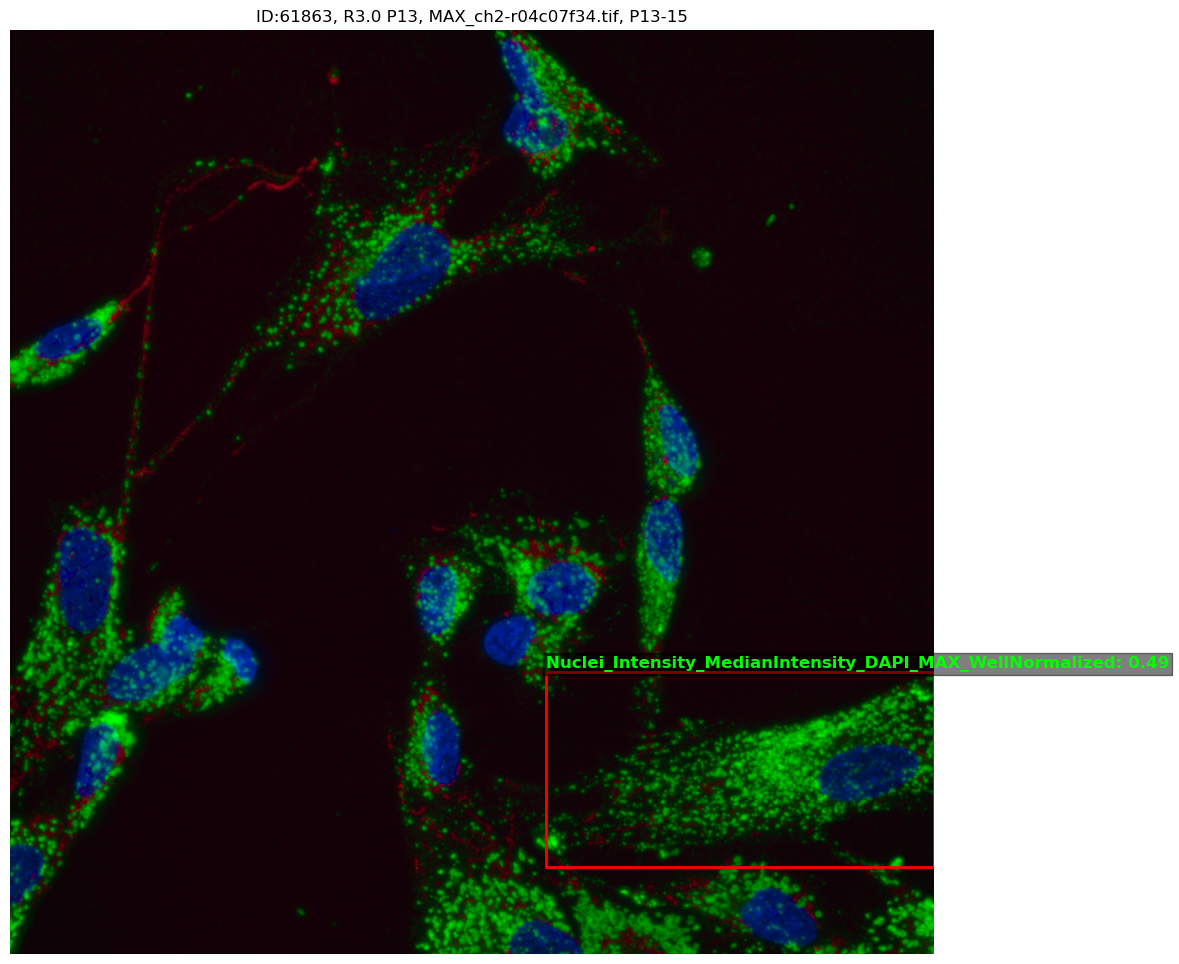

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/20241018_rep03/MAX_ch4-r04c07f34.tif
MAX_ch2-r04c07f34.png
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized/R3.0_P13_MAX_ch2-r04c07f34_61863.png


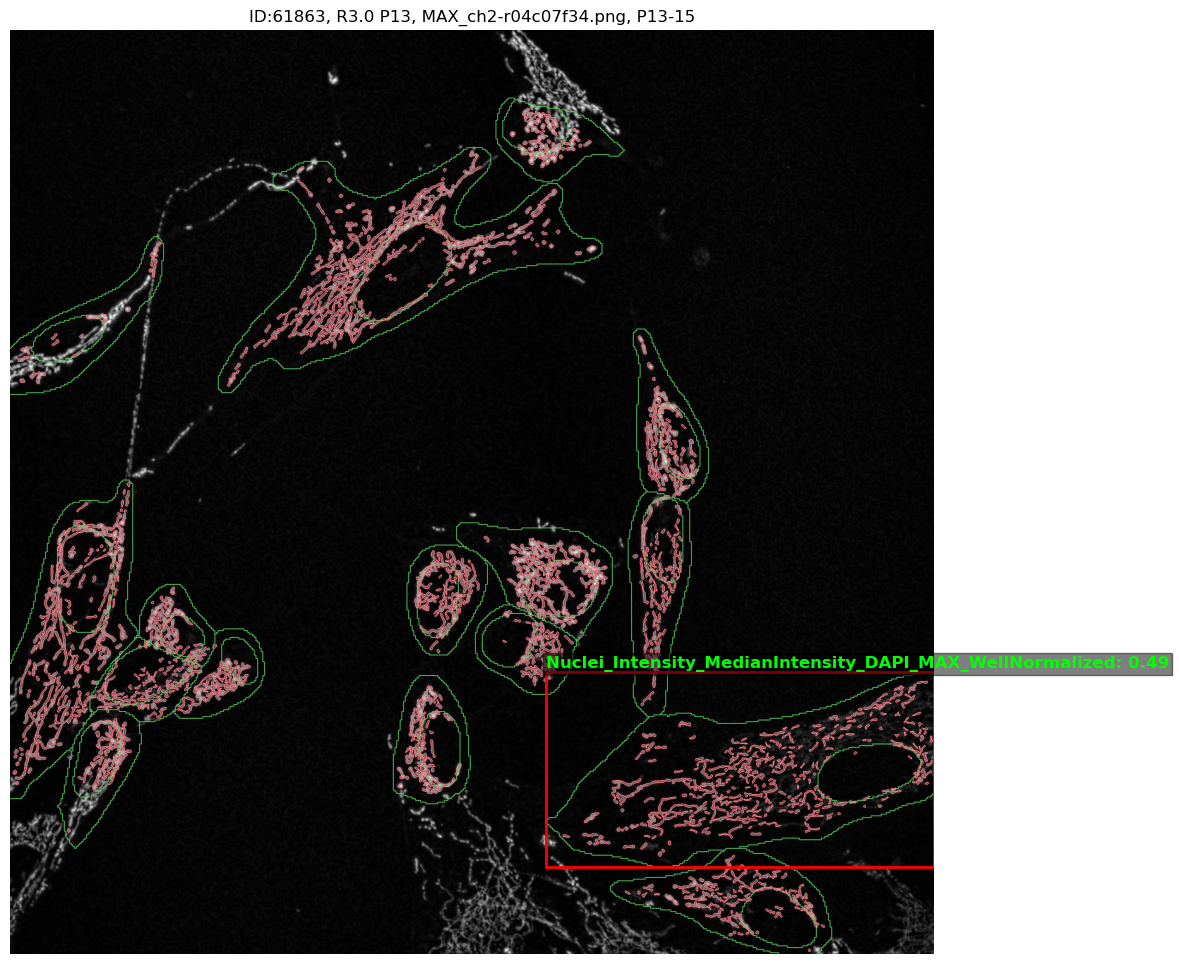

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20241018_rep03_output/v10_active/MAX_ch2-r04c07f34.png
MAX_ch1-r04c07f34.png
Saved image to: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized/R3.0_P13_MAX_ch1-r04c07f34_61863.png


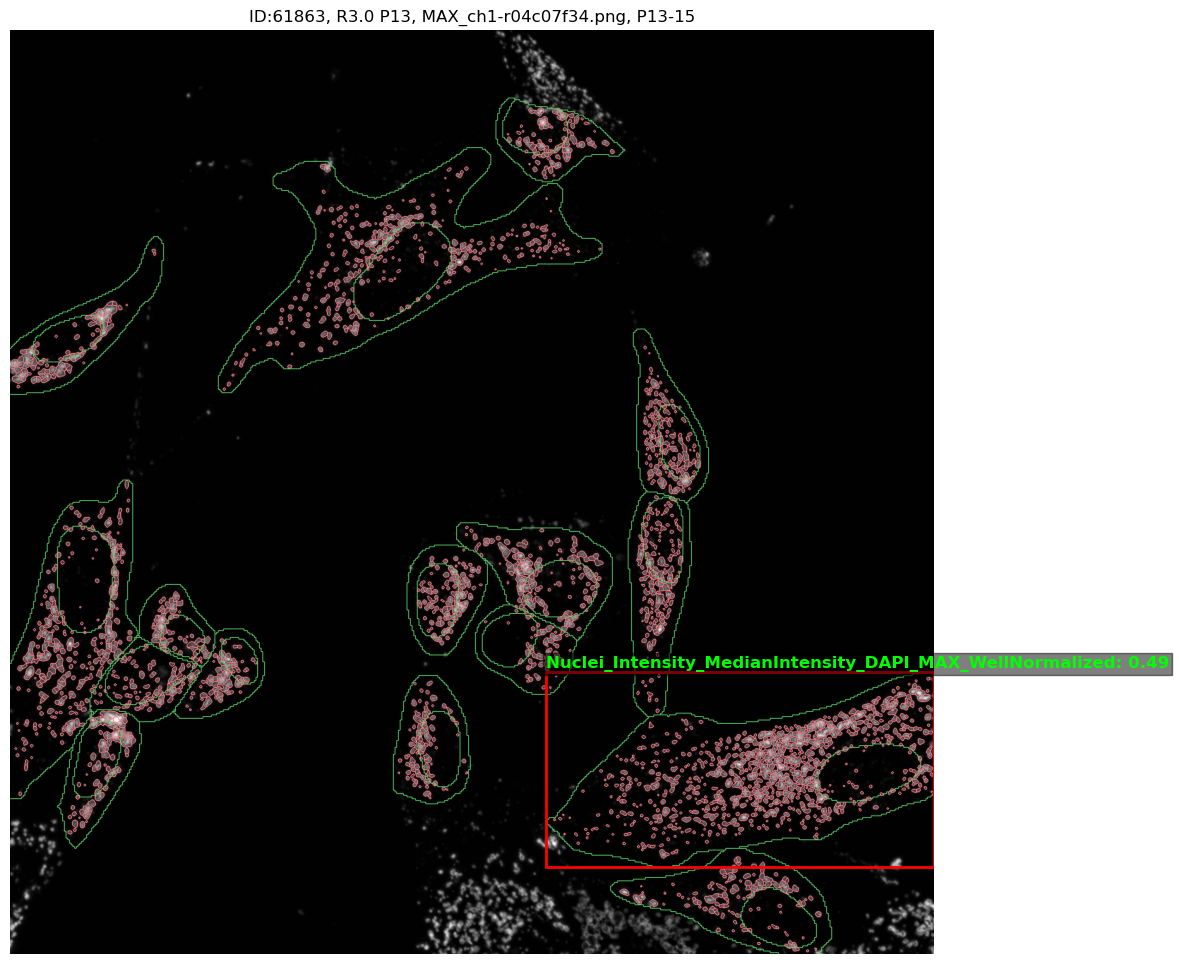

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20241018_rep03_output/v10_active/MAX_ch1-r04c07f34.png


In [89]:
object_key = 61863
savepath = (
    f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/{feature_meas}"
    #f"plots/test_manualanalysis/{feature_meas}"
)
os.makedirs(savepath, exist_ok=True)
pull_up_multichannel_image_fromID(
    filtered_df_to_filter,
    object_key=object_key,
    parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
    image_channels=["MitoTracker", "LAMP1", "DAPI"],
    feature=feature_meas,
    extension=".tif",
    save=True,
    savepath=savepath,
    show=True,
    # colour_map="Blues_r",
)
for compartment in ["MitoTracker", "LAMP1"]:
    
        pull_up_cp_segmentation_image_fromID(
            filtered_df_to_filter,
            object_key=object_key,
            parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
            image_channel=compartment,
            feature=feature_meas,
            save=True,
            savepath=savepath,
        )



In [92]:
def get_object_keys_from_filenames(path, target_folder_name):
    """Get the unique object keys from the dataframe that match a given filename in a directory"""
    object_keys = []
    for root, dirs, files in os.walk(path):
        for file in files:
            if target_folder_name in root and file.endswith(".png"):
                # Extract the unique object key from the filename
                # Assuming the filename format is something like "R5.0_P11_MAX_ch1-r06c10f21.png_51559.png"
                key_part = file.split("_")[-1].split(".")[
                    0
                ]  # Get the last part before .png
                try:
                    object_key = int(key_part)  # Convert to integer
                    if object_key not in object_keys:  # Avoid duplicates
                        object_keys.append(object_key)
                except ValueError:
                    print(f"Could not convert {key_part} to an integer.")

    return object_keys


keys_to_use = get_object_keys_from_filenames(
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/",
    "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
)
display(keys_to_use)

[5145,
 25978,
 4198,
 61,
 48566,
 16195,
 27604,
 51621,
 49094,
 71010,
 70296,
 6725,
 49386,
 45043,
 18239,
 2662,
 13179,
 47459,
 41692,
 34088,
 22770,
 27335,
 41695,
 6837,
 38796,
 23067,
 7605,
 21635,
 69305,
 25289,
 27364,
 22883,
 1847,
 29561,
 63152,
 75290,
 36752,
 72600,
 46332,
 44113,
 31938,
 28061,
 29338,
 48999,
 25144,
 54614,
 40697,
 66597,
 75857,
 27391,
 7032,
 7785,
 13478,
 49833,
 61863,
 21636,
 75984,
 7216,
 51157,
 9593,
 11390,
 69360,
 48174,
 48315,
 45090,
 70168,
 73666,
 42509,
 49679,
 72697,
 2091]

In [ ]:
for key in keys_to_use:
    object_key = key
    for feature_meas in [
        "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
        "Nuclei_Intensity_MedianIntensity_DAPI_MAX_WellNormalized",
        "Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized",
        "Nuclei_Intensity_MaxIntensity_DAPI_MAX_WellNormalized",     
    ]:
        savepath = f"/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/quality_control_curation/test_manualanalysis/{feature_meas}"
        os.makedirs(savepath, exist_ok=True)
        pull_up_multichannel_image_fromID(
            filtered_df_to_filter,
            object_key=object_key,
            parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/MRC-5_MAX_SUM_PROJ/",
            image_channels=["MitoTracker", "LAMP1", "DAPI"],
            feature=feature_meas,
            extension=".tif",
            save=True,
            savepath=savepath,
            show=False,
            # colour_map="Blues_r",
        )
        for compartment in ["MitoTracker", "LAMP1"]:
            pull_up_cp_segmentation_image_fromID(
                filtered_df_to_filter,
                object_key=object_key,
                parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
                image_channel=compartment,
                feature=feature_meas,
                save=True,
                savepath=savepath,
                show=False,
            )


> NOTE:
> R4 appears to have used the wrong masks from cellprofiler!! nuclei look fine but cells are over the wrong image
> e.g Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20241112_rep04_output/v5_active/MAX_ch2-r02c05f20.png

MAX_ch1-r07c11f40.png


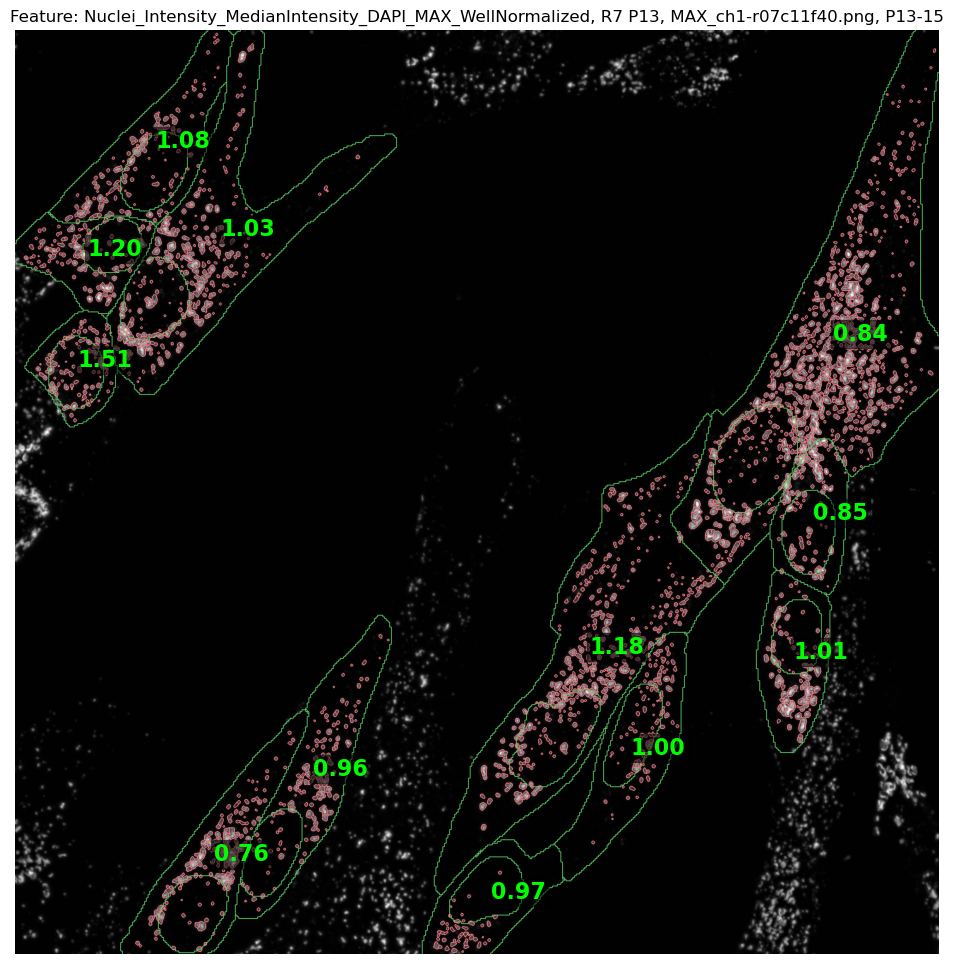

Segmented image url: /mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/20250501_rep07_output/v4_active/MAX_ch1-r07c11f40.png


True

In [16]:
img_filename = "MAX_ch1-r07c11f40.tif"
savepath = f"plots/test_manualanalysis/{feature_meas}_annotations"
query_plate_number = 7

os.makedirs(savepath, exist_ok=True)
annotate_cp_segmentation_image_with_feature_values(
    filtered_df_to_filter,
    img_filename=img_filename,
    plate=query_plate_number,
    group=group,
    parent_dir="/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output",
    feature=feature_meas,
    save=True,
    savepath=savepath,
    decimals=2,
)
# check this out https://www.youtube.com/watch?v=TowK3DMUcaE

# It's plotting time


## Most interesting features so far
- Intensity_MassDisplacment_MitoTracker - increase
- Median Mitochondria Location CenterMass Intensity X
  - decrease,splits into bimodal
  - similar for y
  - AreaShape_Center_X and Center_Y also have similar pattern
  - And Location_Center
- Median mitochondria loaction max intensity
  - Same as CenterMass
- Mean Mitochondria Solidity - increase to p29
- Children Mitochondria Count - gradual increase
  - But scales with size - Density is not sig (slight increase)
  - Total mito area increases; complements this
- Mean Mito Centroid distance - increased (more peripheral)
  - But median is much more vairable between batches
- Mean Mito Trunks - decreased
- Median mito area per cell area - increased
### Lysosomes
- Total area also goes up
- rep3 looks like an outlier here
- Also has the location_ maxintensity change and go bimodal
- bimodal-looking intensity
### Nuclei
- Nuc area increases; scales with cell size increases
- solidity, extent down
- Nuc area ratio - slight increase


## Distribution plots

In [ ]:
# Functions to visualize the distributions
# Define and use a simple function to label the plot in axes coordinates
def ridge_label(x, color, label):
    ax = plt.gca()
    ax.text(
        -0.1,
        -0.2,
        label,
        fontweight="bold",
        color=color,
        ha="left",
        va="center",
        transform=ax.transAxes,
    )


def seaborn_ridgeplot(
    df,
    value_col,
    group_col,
    palette=None,
    bw_adjust=1,
    xlabel=None,
    xlim=(None, None),
    title=None,
    fill_alpha=1,
    linewidth=1.5,
    figsize=(20, 30),
    save=True,
    out_dir="",
    show_percentiles=True,
    truncate_outliers=True,
    norm=False,
):
    """
    Make a ridgeline (joyplot) using seaborn FacetGrid and kdeplot
    Args:
        df: DataFrame
        value_col: str, column with numeric values
        group_col: str, column with group/category
        palette: seaborn palette or list/dict of colors
        bw_adjust: float, KDE bandwidth adjust
        xlabel: str or None
        title: str or None
        fill_alpha: float, alpha for fill
        linewidth: float, line width for outline
        figsize: tuple, figure size
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

    unique_groups = df[group_col].unique()
    if palette is None:
        palette = sns.cubehelix_palette(len(unique_groups), rot=-0.25, light=0.7)
    else:
        palette = palette

    if truncate_outliers and xlim == (None, None):
        try:
            if norm:
                top_fence = df[value_col].mean() + 10 * df[value_col].std()
                bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            else:
                top_fence = np.percentile(df[value_col], 99.9)
                bottom_fence = np.percentile(df[value_col], 0.01)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
                if (
                    bottom_fence == 0
                    or np.isnan(bottom_fence)
                    or np.isinf(bottom_fence)
                ):
                    bottom_fence = None
            xlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            xlim = (None, None)
        print(f"Truncating outliers at: {xlim}")
        xmin, xmax = xlim
        plot_df = df.copy()
        if xmin is not None:
            plot_df = plot_df[plot_df[value_col] >= xmin]
        if xmax is not None:
            plot_df = plot_df[plot_df[value_col] <= xmax]
    else:
        plot_df = df.copy()
    # Initialize the FacetGrid object
    g = sns.FacetGrid(
        plot_df,
        row=group_col,
        hue=group_col,
        aspect=15,
        height=0.5,
        palette=palette,
        xlim=xlim,
    )
    # Draw the densities in a few steps
    g.map(
        sns.kdeplot,
        value_col,
        bw_adjust=bw_adjust,
        clip_on=False,
        fill=True,
        alpha=fill_alpha,
        linewidth=linewidth,
    )
    g.map(sns.kdeplot, value_col, clip_on=False, color="w", lw=2, bw_adjust=bw_adjust)

    if show_percentiles:
        percentiles = [5, 12.5, 25, 50, 75, 87.5, 95]
        for ax in g.axes.flatten():
            # group label text (FacetGrid puts "group_col = <value>" in the title)
            title_text = ax.get_title()
            if " = " in title_text:
                group_val = title_text.split(" = ", 1)[1]
            else:
                group_val = title_text

            group_data = df[df[group_col] == group_val][value_col].dropna()
            if group_data.empty:
                continue

            # pick the most representative line on the axis (the KDE line)
            lines = ax.get_lines()
            if not lines:
                continue
            # choose the line with the largest x-range (robust against multiple lines)
            kde_line = max(lines, key=lambda l: np.ptp(l.get_xdata()))
            xs = kde_line.get_xdata()
            ys = kde_line.get_ydata()
            # line_colour = kde_line.get
            # compute median and interpolate its KDE height
            median = np.median(group_data)
            height = np.interp(median, xs, ys, left=0.0, right=0.0)

            # draw a solid thicker median line from y=0 up to the KDE height
            ax.vlines(
                median, 0, height, color="black", linewidth=3, linestyle=":", zorder=4
            )
            ax.set_xlim(xlim)
            # draw lighter dashed lines for the percentiles (optional)
            group_percentiles = np.percentile(group_data, percentiles)
            for p in group_percentiles:
                ax.vlines(p, 0, height, color="dimgray", ls=":", alpha=0.6, linewidth=2)
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

    g.map(ridge_label, value_col)

    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-0.25)
    g.figure.set_size_inches(figsize)
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="", xlim=xlim)
    g.despine(bottom=True, left=True)
    if xlabel:
        plt.xlabel(xlabel, fontweight="bold", fontsize=14)
    else:
        plt.xlabel(value_col, fontweight="bold", fontsize=14)
    if title:
        g.figure.suptitle(title, ha="right", fontsize=18, fontweight="bold")
    plt.xlim(xlim)
    plt.tight_layout()
    if save:
        plt.savefig(f"{Path(out_dir, f'{value_col}_{group_col}_joyplot')}.png")
    plt.show()


def plotly_histogram(df, y_value, group_var, save=False, out_dir=""):
    import kaleido

    df_sorted = df.sort_values(
        by=[group_var], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    hist2 = px.histogram(
        df_sorted,
        x=y_value,
        color=group_var,
        marginal="box",
        # histnorm='probability density',
        # range_x=(0, top_fence),
    )
    hist2.write_image(Path(out_dir, f"{y_value}_histogram.png"), scale=1.5)
    hist2.show()


In [ ]:
test_ridgeplot = seaborn_ridgeplot(
    final_filtered_df,
    value_col="AreaShape_Area",
    group_col="AllGroups",
    palette="Set2",
    save=False,
    show_percentiles=True,
    truncate_outliers=True,
    figsize=(20, 30),
)


In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="violinplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "violinplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    # nonparametric tests
    if test_name in ["kruskal", "dunn", "kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["drubin", "drubin_posthoc"]:
        used_pairs, p_values = kruskal_with_drubin_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["conover", "con", "kruskal-conover"]:
        used_pairs, p_values = kruskal_with_conover_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["nemenyi", "kruskal-nemenyi"]:
        used_pairs, p_values = kruskal_with_nemenyi_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
            p_correction=p_correction,
        )
    # parametric tests
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name in ["games", "games-howell"]:
        used_pairs, p_values = pvalues_anova_with_games_howell_pingouin(
            data,
            pivot_data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["tahmane", "tahmane-t2"]:
        used_pairs, p_values = anova_with_tahmane_posthoc(
            data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v2", "tukey_posthocs"]:
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v3", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["pairwise_ttest" or "multiple_ttest"]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=True,
            display=True,
        )
    elif test_name in [
        "pairwise_mwu"
        or "multiple_mwu"
        or "pairwise_mannwhitney"
        or "multiple_mannwhitney"
        or "pairwise_wilcoxon"
        or "multiple_wilcoxon"
    ]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=False,
            display=True,
        )
    elif test_name in ["ttest_posthoc", "welch's_posthoc", "tt_posthoc"]:
        used_pairs, p_values = anova_with_corr_ttest_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_corr=p_correction,
            display_results=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', 'games-howell', 'drubin', 'tukey_v2', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)

    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        # fill = True
        width=1,
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
    )
    # add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction,
                annotation_location=annotation_location,
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10 * data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)
    else:
        axlim = (None, None)

    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f'{y_value}_{plate_col_name}_histogram')}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(
            df_sorted,
            value_col=y_value,
            group_col=x_value,
            palette="Set2",
            save=True,
            out_dir=out_dir,
            show_percentiles=True,
        )
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="ticks", context=context, font_scale=font_scale)

    feature_df = df_sorted[[x_value, y_value, plate_col_name]].copy()
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")

    # remove outluers
    if remove_outliers is True:
        if rm_outliers_method == "mad":
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=50
            )
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=500
            )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == "iqr":
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        # display(feature_df)

    # group by plate and condition
    group_avg_df = feature_df.groupby([x_value, plate_col_name], as_index=False).mean()
    # sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)

    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction,
        annotation_location=annotation_location,
    )

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            title=plate_col_name,
        )
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            # display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_", " "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)

    # Set the ylim and don't throw an inf
    if ylim is None:
        ylim = axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine(trim=True)
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

In [ ]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
this_df = norm_combined_cell_df_mitolyso.copy()

data_df = this_df  # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (13, 12)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density

In [ ]:
# Lineage Version
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"
stat_grouping = "Lineage"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
data_df = this_df

# Uncomment this if the fix to add "doxo_" to the doxo lineages is not set
# no_drug_values = {None,"", "None", "none", "NoDrug", "Control", "control"}

# drug_clean = data_df["Drug"].astype(str).str.strip()
# data_df["Lineage"] = data_df["Lineage"].where(
#     data_df["Drug"].isna() | drug_clean.isin(no_drug_values),
#     drug_clean + "_" + data_df["Lineage"].astype(str),
# )

data_df["Lineage"] = data_df["Lineage"].replace(
    "LIN3-0A-b2-s2-ss1-ss1", "LIN3-0A-b2-s2-ss1-sss1"
)
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-ss1"),
#     data_df["Lineage"].equals("LIN3-0A-b2-s2-ss1-sss1"),
# )


def get_hard_code_lineage_colours(
    df, lineage_col_name="Lineage", plate_col_name="Plate_Number"
):
    """
    Returns a dictionary mapping each unique lineage number to a hard-coded color.
    This ensures color consistency for each Plate_Number in seaborn/matplotlib plots.
    """
    # Get colour codes from my csv and then convert it into a dict in the {key: #hexcode} format
    colour_codes = pd.read_csv("proliferation_growth_curves/Lineage_only_hexcolour.csv")
    hard_pallete_dict = dict(
        zip(colour_codes[lineage_col_name], colour_codes["Colour"])
    )

    # print(hard_pallete_dict)
    unique_lineages = sorted(df[lineage_col_name].drop_duplicates())
    # display(unique_lineages)

    # If more lineages than colors, fill in missing colours by using a default seaborn color_palette
    for lineage in unique_lineages:
        if lineage not in hard_pallete_dict:
            extra_colours = sns.color_palette("tab20", len(unique_lineages)).as_hex()
            hard_pallete_dict = {
                lineage: extra_colours[i] for i, lineage in enumerate(unique_lineages)
            }
    return hard_pallete_dict


lindict = {
    "LIN1-0B-b1": "#8000FF",
    "LIN2-0A-b1": "#304CC9",
    "LIN3-0A-b2": "#02FD68",
    "LIN4-0B-b2": "#FFF604",
    "LIN5-0B-b3": "#FFDC00",
    "LIN6-0C-b1": "#FFA000",
    "LIN2-0A-b1-s1": "#87A5FF",
    "LIN3-0A-b2-s1": "#01FDBD",
    "LIN4-0B-b2A-s1": "#E0E102",
    "LIN5-0B-b3-s1": "#958300",
    "LIN6-0C-b1-s1": "#FFB479",
    "LIN3-0A-b2-s2-ss1": "#87FE02",
    "LIN7-0C-b3": "#FF7100",
    "LIN8-0B-b2B-s1": "#FF3200",
    "LIN9-0C-b2-s1": "#FF768A",
    "LIN10-0C-b4": "#A770A3",
    "Doxo_LIN13-0C-b2-s3": "#808080",
    "LIN3-0A-b2-s1-ss1": "#00F0FF",
    "LIN3-0A-b2-s1-ss1-sss1": "#00D7FF",
    "LIN3-0A-b2-s1-ss2": "#019BFF",
    "LIN3-0A-b2-s2-ss1-sss1": "#D5FF93",
    "LIN7-0C-b3-s1": "#FF8F85",
    "LIN8-0B-b2B-s1-ss1": "#D2372C",
    "LIN8-0B-b2B-s1-ss2": "#8C1600",
    "LIN6-0C-b1-s2": "#FFD7AD",
    "LIN11-0C-b5": "#FF2E9D",
    "Doxo_LIN11-0C-b5": "#780A78",
    "LIN12-0C-b2-s2": "#FF23FF",
    "Doxo_LIN12-0C-b2-s2": "#BE12D9",
    "LIN2-0A-b1-s1-ss1": "#A8DAFC",
    "LIN7-0C-b3-s2": "#D0A38C",
    "LIN11-0C-b5-s1": "#FFBFFF",
}
# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_lineage_colours(data_df)
pallete = lindict

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/lineage"
os.makedirs(plot_dir, exist_ok=True)

figsize = (11, 18)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name=stat_grouping,
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=False,
    truncate_outliers=True,
    legend=True,
    context="talk",
    figsize=figsize,
    pallete=pallete,
    shapiro=False,
    # p_correction="fdr_bh",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density


## Make multiple plots as defined

In [ ]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            data_df = data_df[data_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context="talk",
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=True,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 12),
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
)

In [ ]:
def make_a_shitton_of_plots(
    order=[],
    xlabel="Age Groups",
    group="AllGroups",
    pairs=getpairs(combined_cell_df_mitolyso, group, order),
    pallete=colour_dict,
    remove_outliers=False,
    truncate_outliers=True,
    reps_to_exclude=[],
    norm=False,
):
    if not order:
        order = get_all_group_order()

    if norm:
        this_df = norm_combined_cell_df_mitolyso.copy()
        big_out_folder = (
            "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/norm"
        )
    else:
        this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
        big_out_folder = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/plots/notnorm"
    os.makedirs(big_out_folder, exist_ok=True)
    # iterate and make big ball of plots
    for compartment, feature_dict in zip(feature_names, feature_dicts):
        feature_folder = Path(big_out_folder, compartment)
        Path.mkdir(feature_folder, exist_ok=True)
        for feature_type, features in feature_dict.items():
            newfolder = Path(feature_folder, feature_type)
            Path.mkdir(newfolder, exist_ok=True)
            for feature in features:
                single_feature_super_splitviolinplot(
                    this_df,
                    x_value=group,
                    y_value=feature,
                    plate_col_name="Plate_Number",
                    xtitle=xlabel,
                    ytitle=None,
                    out_dir=newfolder,
                    annotate=True,
                    order=order,
                    test="tukey_v3",
                    reps_to_exclude=reps_to_exclude,
                    show_hist=False,
                    remove_outliers=remove_outliers,
                    truncate_outliers=truncate_outliers,
                    show=False,
                    legend=True,
                    context="poster",
                    figsize=(14, 18),
                    pallete=pallete,
                    shapiro=False,
                    p_correction="fdr_bh",
                )


# make_a_shitton_of_plots(reps_to_exclude=[],norm=False)
make_a_shitton_of_plots(reps_to_exclude=[], norm=True)

## Attempting PCA

In [ ]:
vars = cell_features["areashape"]
vars = vars + nuc_features["areashape"]
vars = vars + mito_features["areashape"]
vars = vars + lyso_features["areashape"]
vars = vars + mito_features["texture"]
vars = vars + lyso_features["texture"]
vars = vars + mito_features["count"]
vars = vars + lyso_features["count"]
# vars = vars + mito_features["radialdistribution"]
vars = vars + mito_features["per_cell_area"]
vars = vars + lyso_features["per_cell_area"]
# var = vars + mito_features["granularity"]


# Stratified sampling by group
def stratified_sample(df, group_col, sample_size, random_state=40):
    """
    Take a stratified sample maintaining group proportions
    """
    # Calculate sampling fraction and sample from each group proportionally
    frac = sample_size / len(df)
    sample_df = df.groupby(group_col, group_keys=False).apply(
        lambda x: x.sample(frac=frac, random_state=random_state), include_groups=True
    )
    return sample_df


sample_df = stratified_sample(this_df, "AllGroups", sample_size=10000)

In [ ]:
from sklearn.decomposition import PCA

n_components = 2
pca = PCA(n_components)

x_df = sample_df[vars.__add__(["AllGroups", "Plate_Number", "AreaShape_Area"])].dropna()
display(x_df)
components = pca.fit_transform(x_df[vars])
display(components)

fig = px.scatter(
    components, x=0, y=1, color=x_df["AllGroups"], symbol=x_df["Plate_Number"]
)
total_var = pca.explained_variance_ratio_.sum() * 100

# labels = {str(i): f"PC {i + 1}" for i in range(n_components)}
# labels["color"] = "AllGroups"

# fig = px.scatter_matrix(
#     components,
#     color=x_df["AllGroups"],
#     dimensions=range(n_components),
#     labels=labels,
#     title=f"Total Explained Variance: {total_var:.2f}%",
# )
# fig.update_traces(diagonal_visible=False)
fig.show()

# labels = {
#     str(i): f"PC {i + 1} ({var:.1f}%)"
#     for i, var in enumerate(pca.explained_variance_ratio_ * 100)
# }

# fig = px.scatter_matrix(
#     components, labels=labels, dimensions=range(4), color=df["species"]
# )
# fig.update_traces(diagonal_visible=False)
# fig.show()


In [ ]:
from umap import UMAP
from sklearn.preprocessing import StandardScaler

scaled_data = StandardScaler().fit_transform(x_df[vars])
reducer = UMAP(random_state=40)
reducer.fit(scaled_data)

embedding = reducer.transform(scaled_data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert np.all(embedding == reducer.embedding_)
print(embedding.shape)

import sklearn.cluster as cluster

import sklearn.metrics as metrics


In [ ]:
kmeans_labels = cluster.KMeans(n_clusters=9).fit_predict(scaled_data)

"""
From https://umap-learn.readthedocs.io/en/latest/clustering.html: 
The next thing to be aware of is that when using UMAP for dimension reduction you will want to select different parameters 
than if you were using it for visualization. First of all we will want a larger n_neighbors value 
small values will focus more on very local structure and are more prone to producing fine grained cluster structure 
that may be more a result of patterns of noise in the data than actual clusters. 
In this case well double it from the default 15 up to 30. Second it is beneficial to set min_dist to a very low value. 
Since we actually want to pack points together densely (density is what we want after all) a low value will help,
as well as making cleaner separations between clusters.
In this case we will simply set min_dist to be 0.
"""
clusterable_embedding = UMAP(
    n_neighbors=30,
    min_dist=0.0,
    n_components=2,
    random_state=40,
).fit_transform(scaled_data)

# now plot the embeddings
fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=kmeans_labels.astype(str),  # x_df["Plate_Number"],
    symbol=x_df["AllGroups"].astype(str),
    size=x_df["AreaShape_Area"],
    labels={"color": "kmeans"},
)
fig.show()


# labels = cluster.HDBSCAN(
#     min_samples=10,
#     min_cluster_size=500,
# ).fit_predict(clusterable_embedding)

fig = px.scatter(
    clusterable_embedding,
    x=0,
    y=1,
    color=x_df["Plate_Number"].astype(str),
    # symbol=x_df["Plate_Number"].astype(str),  # x_df["Plate_Number"],
    size=x_df["AreaShape_Area"],
    labels={"color": "Plate Number"},
)
fig.update_legends()
fig.show()


In [ ]:
from umap import plot
# Take a random sample of n rows

new_embedding = UMAP(
    n_components=2,
    n_neighbors=15,
    random_state=40,
).fit(scaled_data)
plot.points(new_embedding, labels=x_df.Plate_Number.astype(str), theme="fire")
plt.savefig("umap_test_2.png")

In [ ]:
# Using one-way anova and Tukey's HSD to compare means of non normalized values
order = get_all_group_order()
feature_meas = "AreaShape_Area"
ylabel = "Area"


group = "AllGroups"
plates = "Plate_Number"
pairs = getpairs(combined_cell_df_mitolyso, group, order)
this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
pallete = "pastel"
remove_outliers = True

feature_df = make_single_feature_df(
    this_df, group=group, feature=feature_meas, plates="Plate_Number"
)
group_avg_df = average_groups_by_plate(
    feature_df, x_value=group, y_value=feature_meas, plates="Plate_Number"
)
group_avg_df_pivot = average_groups_pivot(
    group_avg_df, x_value=group, y_value=feature_meas, plate_col_name="Plate_Number"
)

if remove_outliers is True:
    feature_df = remove_outliers_iqr(feature_df)
    display(feature_df)

display(feature_df)
display(group_avg_df)
display(group_avg_df_pivot)

sns.set_theme(style="ticks")
# sns.set_context("notebook", font_scale=1.9)

plt.figure(figsize=(12, 8))
sns.set_context("talk", font_scale=0.5)
plt.figure(dpi=300)


sns.violinplot(
    data=feature_df,
    x=group,
    y=feature_meas,
    order=order,
    fill=False,
    color="gainsboro",
    cut=1,
    native_scale=True,
    linecolor="k",
    inner=None,
    # inner_kws=dict(box_width = 5)
)

ax = sns.swarmplot(
    data=group_avg_df,
    x=group,
    y=feature_meas,
    hue=plates,
    order=order,
    palette=pallete,
    size=10,
    edgecolor="k",
    linewidth=1,
    dodge=0.5,
)

# use a boxplot to draw the mean line - thinking outside the box :)
sns.boxplot(
    data=group_avg_df,
    x=group,
    y=feature_meas,
    showmeans=True,
    meanline=True,
    meanprops={"color": "dimgray", "ls": "-", "lw": 2.5},
    medianprops={"visible": False},
    whiskerprops={"visible": False},
    zorder=1,
    showfliers=False,
    showbox=False,
    showcaps=False,
    ax=ax,
)

ax.legend_.remove()

sns.despine()
plt.gcf()  # .set_size_inches(10, 6)
plt.xlabel(group)
if ylabel == None:
    plt.ylabel(feature_meas.replace("_", " "))


from statannotations.Annotator import Annotator
from statannotations.stats.StatTest import StatTest

# Extract the data for each group

# Perform the one-way ANOVA test

# Print the results

pvalues, pairs = anova_with_tukey_posthoc(
    group_avg_df, x_value=group, y_value=feature_meas, display_results=True
)


annotator = Annotator(ax, pairs, data=group_avg_df_pivot, order=order)
annotator.configure(
    text_format="star", loc="inside", verbose=2, hide_non_significant=True
)
annotator.set_pvalues_and_annotate(pvalues)

plt.savefig("plots/new_plots/" + feature_meas + "_anova_superviolinplot.png", dpi=300)
plt.show()


## Summary Stats

In [ ]:
summary_outpath = "postprocessed_summary_stats"
os.makedirs(summary_outpath, exist_ok=True)

feature_cols = [
    "AreaShape_Area",
    "AreaShape_Eccentricity",
    "Nuclei_AreaShape_Area",
    "Nuclei_AreaShape_Eccentricity",
    "Cell_Nuclei_Area_Ratio",
    "Nuclei_Intensity_MinIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MeanIntensity_DAPI_MAX_WellNormalized",
    "Nuclei_Intensity_MaxIntensity_DAPI_MAX_WellNormalized",
    "Intensity_MeanIntensity_LAMP1_MAX",
    "Intensity_MeanIntensity_MitoTracker_MAX",
    "Neighbors_NumberOfNeighbors_5",
    "Neighbors_PercentTouching_5",
    "Nuclei_Neighbors_NumberOfNeighbors_1",
    "Nuclei_Neighbors_PercentTouching_1",
    "Children_Lysosomes_Count",
    "Children_Mitochondria_Count",
]
include_cols = ["Number_Object_Number"] + feature_cols
print(include_cols)


def make_summary_stats_for_df_and_feature(
    df,
    x_value,
    feature,
    summary_outpath,
    df_tag="original",
    plate_col_name="Plate_Number",
    feature_name="area",
    group_name="passage_group",
    include_cols=[],
    inculded_percentiles=[
        0.01,
        0.025,
        0.05,
        0.1,
        0.25,
        0.5,
        0.75,
        0.9,
        0.95,
        0.975,
        0.99,
    ],
):
    from pathlib import Path

    try:
        table_csvname = f"{df_tag}_total_combined_stats.csv"
        feature_csvname = f"{df_tag}_{feature_name}_by_{group_name}_stats.csv"
        agg_feature_csvname = f"{df_tag}_agg_{feature_name}_by_{group_name}_stats.csv"

        subfolder_name = f"{df_tag}_{feature_name}_summary_stats"
        parent_folder = Path(summary_outpath, subfolder_name)
        parent_folder.mkdir(exist_ok=True)

        if not include_cols:
            df_to_summarize = df
        else:
            df_to_summarize = df[include_cols]
        df_to_summarize.describe(percentiles=inculded_percentiles).to_csv(
            os.path.join(summary_outpath, table_csvname)
        )
        group_averages = df.groupby(
            [x_value, plate_col_name], as_index=False, observed=True
        )[feature]
        # Reset the index to get a clean DataFrame
        # average_df = group_averages.reset_index()
        avg_summary = group_averages.describe(percentiles=inculded_percentiles)
        avg_summary_sorted = avg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_summary_sorted.to_csv(
            os.path.join(summary_outpath, subfolder_name, feature_csvname)
        )

        # do the agg by passage group only
        group_averages_agg = df.groupby([x_value], as_index=False, observed=True)[
            feature
        ]
        avg_agg_summary = group_averages_agg.describe(percentiles=inculded_percentiles)
        avg_agg_summary_sorted = avg_agg_summary.sort_values(
            by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
        ).reset_index(drop=True)
        avg_agg_summary_sorted.T.to_csv(
            os.path.join(summary_outpath, subfolder_name, agg_feature_csvname)
        )
        print(
            f"saved files {(table_csvname, feature_csvname, agg_feature_csvname)} to {summary_outpath}"
        )
        return True
    except ValueError as e:
        print(f"Could not make summary stats: {e}")
        return False


this_df = extrafeatures_filtered_cell_df_mitolyso.copy()


for feature in feature_cols:
    df_sorted = this_df.sort_values(
        by=["AllGroups"], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    make_summary_stats_for_df_and_feature(
        df_sorted,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="original",
        feature_name=feature,
        include_cols=include_cols,
    )
    seaborn_ridgeplot(
        df_sorted,
        value_col=feature,
        group_col="AllGroups",
        palette="Set2",
        save=True,
        out_dir=summary_outpath,
        show_percentiles=True,
        truncate_outliers=True,
    )


### To export the normalized csv:


In [ ]:
combined_cell_df_mitolyso_borders_excluded = pd.read_csv(
    os.path.join(csvpath, filename_borders_excluded)
)
filtered_borders_excluded = apply_all_filters(
    combined_cell_df_mitolyso_borders_excluded
)

for feature in feature_cols:
    make_summary_stats_for_df_and_feature(
        filtered_borders_excluded,
        "AllGroups",
        feature,
        summary_outpath,
        df_tag="borders_excluded",
        feature_name=feature,
        include_cols=include_cols,
    )


In [ ]:
preprocessed_df = extrafeatures_filtered_cell_df_mitolyso.copy()

preprocessed_df.to_csv(
    os.path.join(csvpath, "CellProfiler_features_preprocessed.csv"), index=False
)

norm_cell_df_mitolyso.to_csv(
    os.path.join(csvpath, "Norm_CellProfiler_features_preprocessed.csv"),
    index=False,
)